# 02e — Multivariate Analysis & LSOA Archetype Clustering

**Purpose:** Move beyond pairwise analysis. Which LSOAs are deprived on
MULTIPLE dimensions simultaneously? What are the natural groupings
(archetypes) of LSOAs when we consider all 8 factors together?

**Sections:**
1. Build the multivariate LSOA feature matrix (all 8 factors)
2. Correlation matrix — full 8-factor view
3. PCA — dimension reduction to find dominant patterns
4. K-Means clustering — LSOA archetypes
5. Cluster profiling — what defines each archetype
6. Multi-deprivation: LSOAs deprived on 3+ dimensions
7. Violin plots — distribution deep dives by cluster

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import warnings
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

RAW = Path('/Users/souravamseekarmarti/Projects/aequitas/data/raw')
AUDIT = Path('/Users/souravamseekarmarti/Projects/aequitas/data/audit')

## 1. Build the Full Feature Matrix

One row per LSOA, one column per factor + key sub-dimensions.

In [2]:
# Load all datasets
print("Loading datasets...")

# IMD
imd = pd.read_csv(RAW / 'imd' / 'imd2025_all_ranks_scores_deciles.csv')
imd_code = [c for c in imd.columns if 'LSOA' in c and 'code' in c.lower()][0]
imd_score = [c for c in imd.columns if c.startswith('Index of Multiple') and 'Score' in c][0] if any('Index of Multiple' in c and 'Score' in c for c in imd.columns) else [c for c in imd.columns if 'IMD' in c and 'Score' in c][0]
imd_decile = [c for c in imd.columns if 'Decile' in c and ('IMD' in c or 'Index of Multiple' in c)][0]

# Get domain scores
domain_map = {}
for domain, kw in [('income', 'income'), ('employment', 'employment'),
                     ('education', 'education'), ('health', 'health'),
                     ('crime', 'crime'), ('barriers', 'barrier'), ('living_env', 'living')]:
    candidates = [c for c in imd.columns if kw in c.lower() and 'Score' in c
                  and 'sub' not in c.lower() and 'children' not in c.lower()
                  and 'adult' not in c.lower() and 'geographical' not in c.lower()
                  and 'wider' not in c.lower() and 'indoor' not in c.lower()
                  and 'outdoor' not in c.lower() and 'IDACI' not in c and 'IDAOPI' not in c]
    if candidates:
        domain_map[domain] = candidates[0]

# Sub-domains
geo_barriers = [c for c in imd.columns if 'geographical' in c.lower() and 'Score' in c]
idaci = [c for c in imd.columns if 'IDACI' in c and 'Score' in c]
idaopi = [c for c in imd.columns if 'IDAOPI' in c and 'Score' in c]

# Population
pop = pd.read_csv(RAW / 'census' / 'census2021_ts001_lsoa_population.csv')
pop_total_col = [c for c in pop.columns if 'Total' in c and 'measures' in c][0]
pop = pop[pop['geography code'].str.startswith('E')][['geography code', pop_total_col]].rename(
    columns={pop_total_col: 'population'})

# Age
with zipfile.ZipFile(RAW / 'census' / 'census2021-ts007a.zip') as z:
    csvname = [n for n in z.namelist() if n.endswith('-lsoa.csv')][0]
    age = pd.read_csv(z.open(csvname))
age = age[age['geography code'].str.startswith('E')]
age_total = [c for c in age.columns if 'Total' in c and c != 'date'][0]
elderly_cols = [c for c in age.columns if any(kw in c for kw in ['65 to 69', '70 to 74', '75 to 79', '80 to 84', '85 and over', '85 years'])]
age['elderly_pct'] = age[elderly_cols].sum(axis=1) / age[age_total] * 100

# Car ownership
with zipfile.ZipFile(RAW / 'census' / 'census2021-ts045.zip') as z:
    csvname = [n for n in z.namelist() if n.endswith('-lsoa.csv')][0]
    car = pd.read_csv(z.open(csvname))
car = car[car['geography code'].str.startswith('E')]
car_total = [c for c in car.columns if 'Total' in c][0]
car_nocar = [c for c in car.columns if 'No cars' in c][0]
car['nocar_pct'] = car[car_nocar] / car[car_total] * 100

# Ethnicity
with zipfile.ZipFile(RAW / 'census' / 'census2021-ts021.zip') as z:
    csvname = [n for n in z.namelist() if n.endswith('-lsoa.csv')][0]
    eth = pd.read_csv(z.open(csvname))
eth = eth[eth['geography code'].str.startswith('E')]
eth_total = [c for c in eth.columns if 'Total: All usual' in c][0]
white_col = [c for c in eth.columns if c.startswith('Ethnic group: White') and 'English' not in c
             and 'Irish' not in c and 'Gypsy' not in c and 'Roma' not in c and 'Other' not in c]
if white_col:
    eth['nonwhite_pct'] = (1 - eth[white_col[0]] / eth[eth_total]) * 100

# Unemployment
unemp = pd.read_csv(RAW / 'nomis' / 'nomis_unemployment_lsoa.csv')
unemp = unemp[unemp['geography code'].str.startswith('E')]
unemp_total = [c for c in unemp.columns if 'Total' in c and 'All usual' in c][0]
unemp_cols = [c for c in unemp.columns if 'Unemployed' in c]
if unemp_cols:
    unemp['unemployment_pct'] = unemp[unemp_cols].sum(axis=1) / unemp[unemp_total] * 100

# RUC
ruc = pd.read_csv(RAW / 'census' / 'ruc2021_lsoa_ew.csv')
ruc_code = ruc.columns[0]
ruc_class_cols = [c for c in ruc.columns if ruc[c].nunique() < 20 and c != ruc_code]
ruc_class = ruc_class_cols[0] if ruc_class_cols else ruc.columns[1]

# NaPTAN stop counts (from master table if available, else compute)
master_path = AUDIT / 'master_lsoa_table.parquet'
if master_path.exists():
    master = pd.read_parquet(master_path)
    stop_data = master[['lsoa_cd', 'stop_count']].rename(columns={'lsoa_cd': 'geography code'})
else:
    print("Master table not found — stop counts will be computed in 02c")
    stop_data = pd.DataFrame(columns=['geography code', 'stop_count'])

print("All datasets loaded.")

Loading datasets...


All datasets loaded.


In [3]:
# Build the feature matrix
features = imd[[imd_code, imd_score, imd_decile]].rename(columns={
    imd_code: 'lsoa_cd',
    imd_score: 'imd_score',
    imd_decile: 'imd_decile',
})

# Add domain scores — merge from imd using the original code column
for name, col in domain_map.items():
    imd_subset = imd[[imd_code, col]].rename(columns={imd_code: 'lsoa_cd', col: f'{name}_score'})
    features = features.merge(imd_subset, on='lsoa_cd', how='left', suffixes=('', f'_{name}'))

# Add sub-domains
if geo_barriers:
    features = features.merge(
        imd[[imd_code, geo_barriers[0]]].rename(columns={imd_code: 'lsoa_cd', geo_barriers[0]: 'geo_barriers_score'}),
        on='lsoa_cd', how='left')
if idaci:
    features = features.merge(
        imd[[imd_code, idaci[0]]].rename(columns={imd_code: 'lsoa_cd', idaci[0]: 'idaci_score'}),
        on='lsoa_cd', how='left')
if idaopi:
    features = features.merge(
        imd[[imd_code, idaopi[0]]].rename(columns={imd_code: 'lsoa_cd', idaopi[0]: 'idaopi_score'}),
        on='lsoa_cd', how='left')

# Add census-derived metrics
features = features.merge(pop.rename(columns={'geography code': 'lsoa_cd'}), on='lsoa_cd', how='left')
features = features.merge(age[['geography code', 'elderly_pct']].rename(columns={'geography code': 'lsoa_cd'}),
                            on='lsoa_cd', how='left')
features = features.merge(car[['geography code', 'nocar_pct']].rename(columns={'geography code': 'lsoa_cd'}),
                            on='lsoa_cd', how='left')
if 'nonwhite_pct' in eth.columns:
    features = features.merge(eth[['geography code', 'nonwhite_pct']].rename(columns={'geography code': 'lsoa_cd'}),
                                on='lsoa_cd', how='left')
if 'unemployment_pct' in unemp.columns:
    features = features.merge(unemp[['geography code', 'unemployment_pct']].rename(columns={'geography code': 'lsoa_cd'}),
                                on='lsoa_cd', how='left')

# Add RUC
features = features.merge(ruc[[ruc_code, ruc_class]].rename(columns={ruc_code: 'lsoa_cd', ruc_class: 'ruc_class'}),
                            on='lsoa_cd', how='left')

# Add stop counts
if len(stop_data) > 0:
    features = features.merge(stop_data.rename(columns={'geography code': 'lsoa_cd'}), on='lsoa_cd', how='left')
    features['stop_count'] = features['stop_count'].fillna(0)
    features['stops_per_1k'] = features['stop_count'] / features['population'] * 1000

print(f"Feature matrix: {len(features):,} rows × {len(features.columns)} columns")
print(f"\nColumns: {list(features.columns)}")
print(f"Nulls:\n{features.isna().sum()[features.isna().sum() > 0].to_string()}")

Feature matrix: 33,755 rows × 21 columns

Columns: ['lsoa_cd', 'imd_score', 'imd_decile', 'income_score', 'employment_score', 'education_score', 'health_score', 'crime_score', 'barriers_score', 'living_env_score', 'geo_barriers_score', 'idaci_score', 'idaopi_score', 'population', 'elderly_pct', 'nocar_pct', 'nonwhite_pct', 'unemployment_pct', 'ruc_class', 'stop_count', 'stops_per_1k']
Nulls:
Series([], )


## 2. Full Correlation Matrix — All 8 Factors

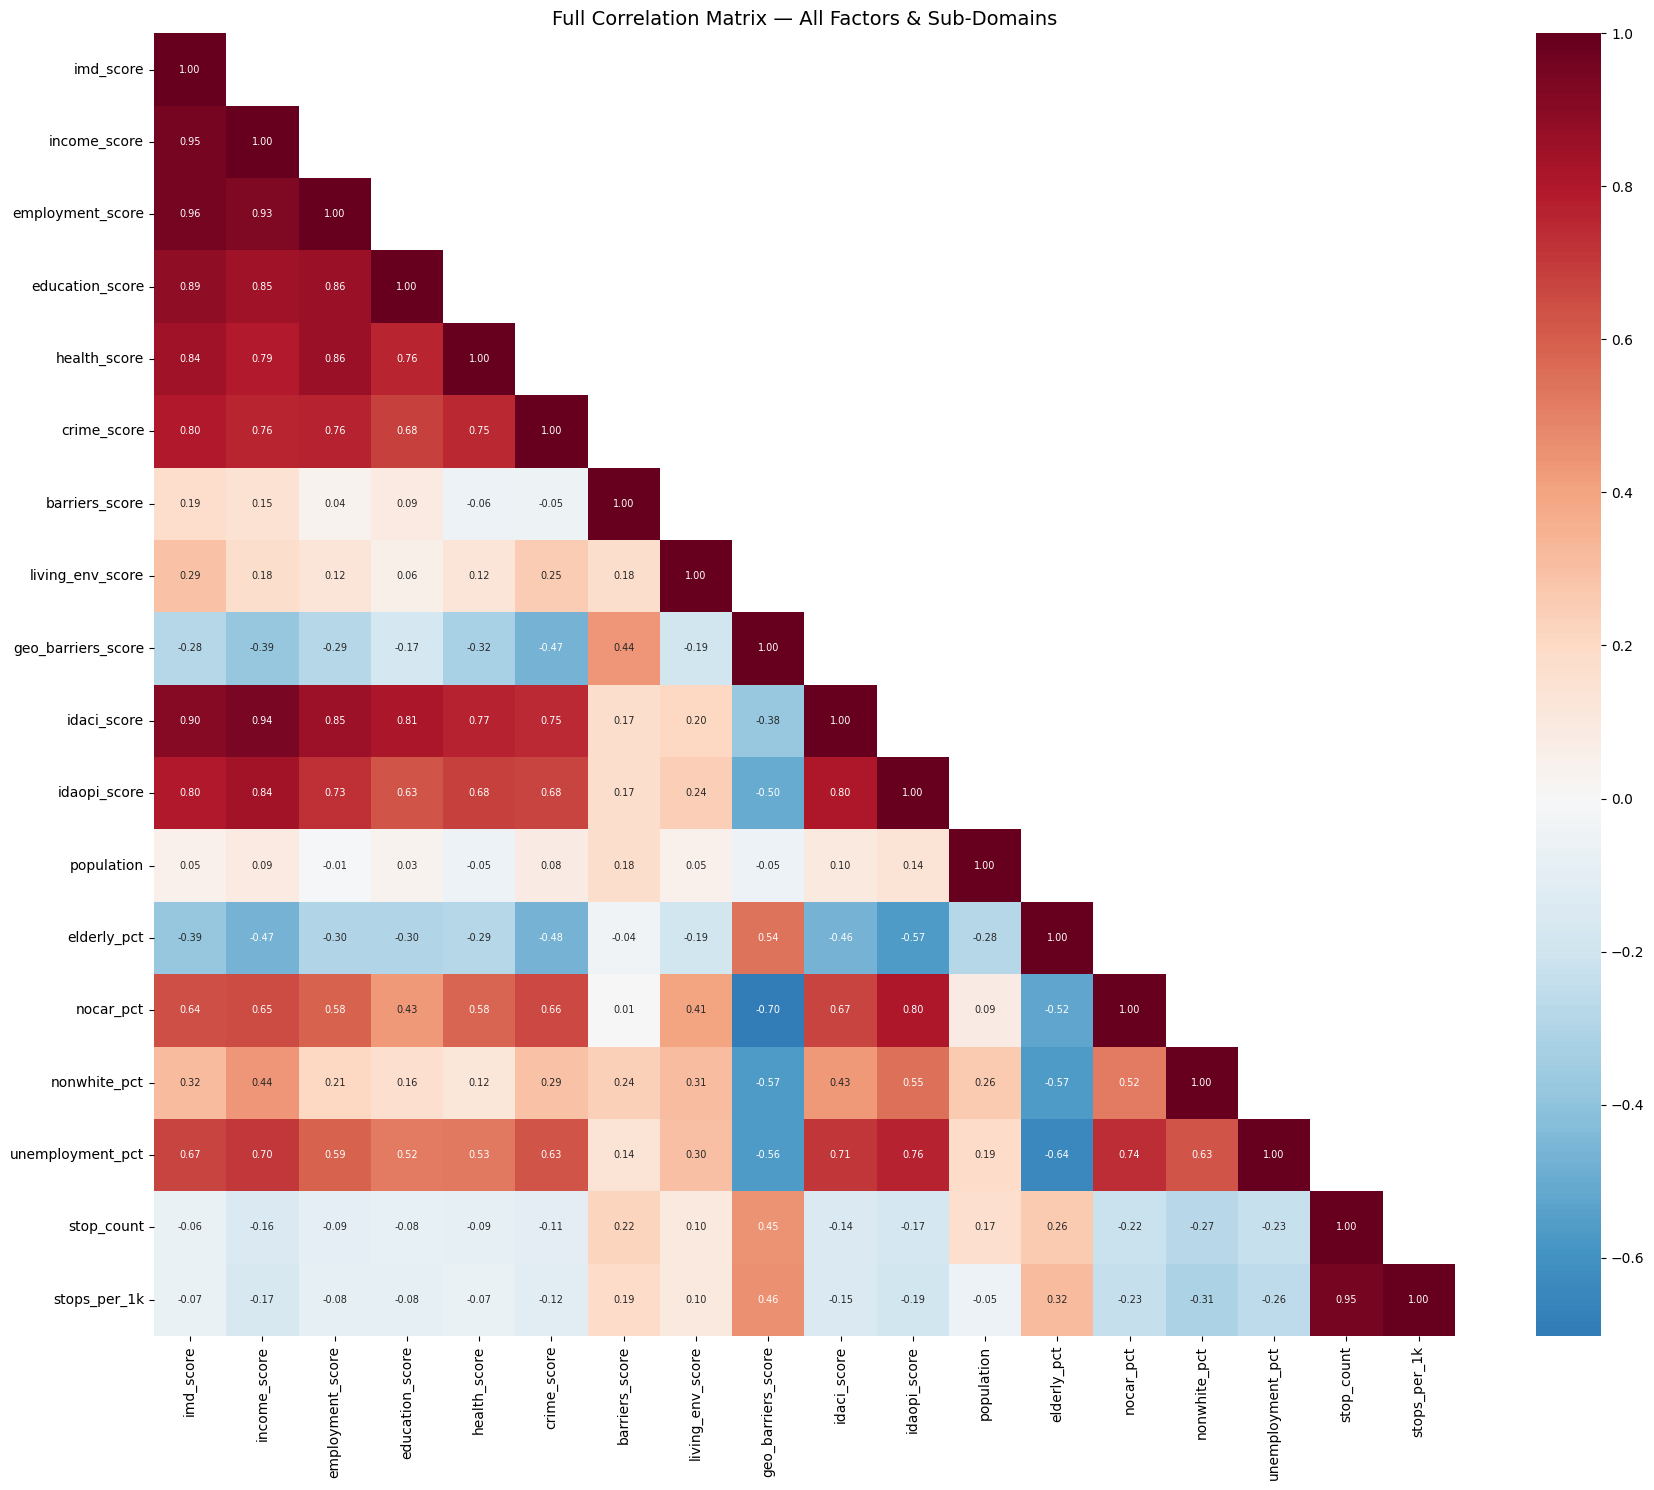

=== Strongest Correlations (|r| > 0.5) ===
  imd_score ↔ employment_score: r=0.957
  imd_score ↔ income_score: r=0.954
  stop_count ↔ stops_per_1k: r=0.953
  income_score ↔ idaci_score: r=0.943
  income_score ↔ employment_score: r=0.929
  imd_score ↔ idaci_score: r=0.900
  imd_score ↔ education_score: r=0.886
  employment_score ↔ health_score: r=0.862
  employment_score ↔ education_score: r=0.857
  employment_score ↔ idaci_score: r=0.853
  income_score ↔ education_score: r=0.846
  imd_score ↔ health_score: r=0.842
  income_score ↔ idaopi_score: r=0.839
  education_score ↔ idaci_score: r=0.810
  idaopi_score ↔ nocar_pct: r=0.803
  idaci_score ↔ idaopi_score: r=0.801
  imd_score ↔ crime_score: r=0.797
  imd_score ↔ idaopi_score: r=0.796
  income_score ↔ health_score: r=0.789
  health_score ↔ idaci_score: r=0.772
  idaopi_score ↔ unemployment_pct: r=0.764
  employment_score ↔ crime_score: r=0.761
  income_score ↔ crime_score: r=0.761
  education_score ↔ health_score: r=0.759
  health_scor

In [4]:
# Select numeric columns for correlation
numeric_cols = features.select_dtypes(include=[np.number]).columns.tolist()
# Remove ID-like columns
exclude = ['imd_decile']
corr_cols = [c for c in numeric_cols if c not in exclude]

fig, ax = plt.subplots(figsize=(18, 15))
corr = features[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax,
            xticklabels=True, yticklabels=True, annot_kws={'size': 7})
ax.set_title('Full Correlation Matrix — All Factors & Sub-Domains', fontsize=14)
plt.tight_layout()
plt.show()

# Top correlations
print("=== Strongest Correlations (|r| > 0.5) ===")
corr_pairs = []
for i in range(len(corr)):
    for j in range(i+1, len(corr)):
        r = corr.iloc[i, j]
        if abs(r) > 0.5:
            corr_pairs.append((corr.index[i], corr.columns[j], r))
corr_pairs.sort(key=lambda x: abs(x[2]), reverse=True)
for a, b, r in corr_pairs:
    print(f"  {a} ↔ {b}: r={r:.3f}")

## 3. PCA — What Are the Dominant Patterns?

PCA input columns (11):
  imd_score: 0 nulls
  unemployment_pct: 0 nulls
  nocar_pct: 0 nulls
  elderly_pct: 0 nulls
  nonwhite_pct: 0 nulls
  income_score: 0 nulls
  employment_score: 0 nulls
  barriers_score: 0 nulls
  living_env_score: 0 nulls
  geo_barriers_score: 0 nulls
  stops_per_1k: 0 nulls
Rows for PCA: 33,755 (dropped 0 with nulls)


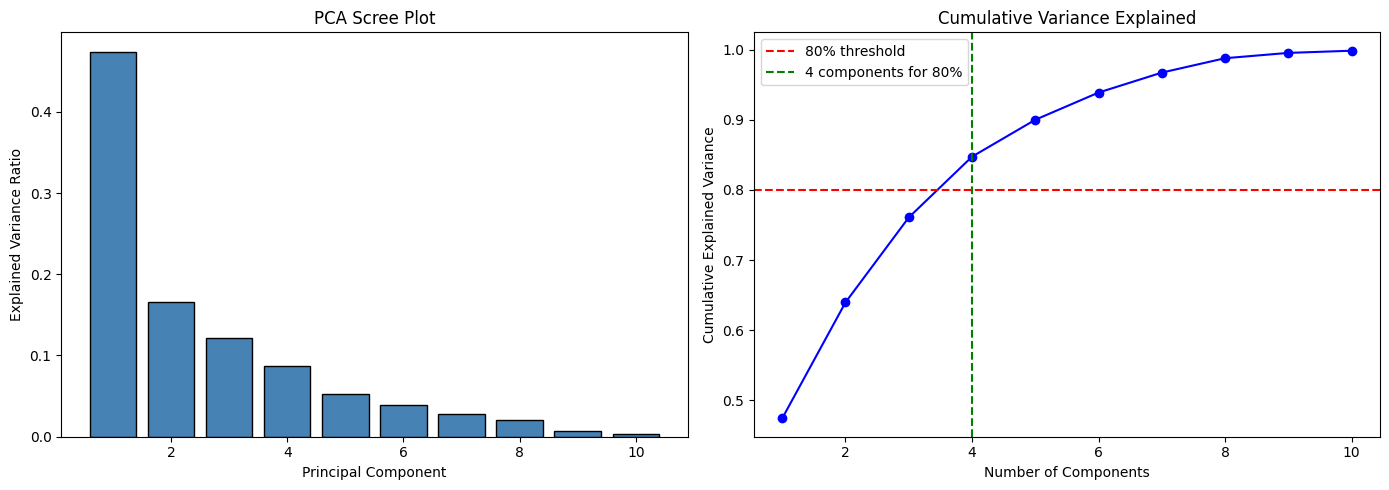


Explained variance per component:
  PC1: 0.474 (cumulative: 0.474)
  PC2: 0.165 (cumulative: 0.640)
  PC3: 0.121 (cumulative: 0.761)
  PC4: 0.087 (cumulative: 0.847)
  PC5: 0.053 (cumulative: 0.900)
  PC6: 0.039 (cumulative: 0.939)
  PC7: 0.028 (cumulative: 0.967)
  PC8: 0.021 (cumulative: 0.988)
  PC9: 0.008 (cumulative: 0.996)
  PC10: 0.003 (cumulative: 0.999)


In [5]:
# Select the 8 core factor columns for PCA
factor_cols = ['imd_score', 'unemployment_pct', 'nocar_pct', 'elderly_pct',
               'nonwhite_pct']
# Add domain scores if available
for c in ['income_score', 'employment_score', 'barriers_score', 'living_env_score']:
    if c in features.columns:
        factor_cols.append(c)
if 'geo_barriers_score' in features.columns:
    factor_cols.append('geo_barriers_score')
if 'stops_per_1k' in features.columns:
    factor_cols.append('stops_per_1k')

# Remove any columns with too many nulls
factor_cols = [c for c in factor_cols if c in features.columns and features[c].isna().mean() < 0.05]
print(f"PCA input columns ({len(factor_cols)}):")
for c in factor_cols:
    print(f"  {c}: {features[c].isna().sum()} nulls")

# Prepare data
pca_data = features[factor_cols].dropna()
print(f"Rows for PCA: {len(pca_data):,} (dropped {len(features) - len(pca_data):,} with nulls)")

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(pca_data)

# PCA
pca = PCA(n_components=min(len(factor_cols), 10))
X_pca = pca.fit_transform(X_scaled)

# Explained variance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(range(1, len(pca.explained_variance_ratio_)+1), pca.explained_variance_ratio_,
            color='steelblue', edgecolor='black')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('PCA Scree Plot')

cumvar = np.cumsum(pca.explained_variance_ratio_)
axes[1].plot(range(1, len(cumvar)+1), cumvar, 'bo-')
axes[1].axhline(0.8, color='r', linestyle='--', label='80% threshold')
n_80 = np.argmax(cumvar >= 0.8) + 1
axes[1].axvline(n_80, color='g', linestyle='--', label=f'{n_80} components for 80%')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('Cumulative Variance Explained')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nExplained variance per component:")
for i, (ev, cev) in enumerate(zip(pca.explained_variance_ratio_, cumvar)):
    print(f"  PC{i+1}: {ev:.3f} (cumulative: {cev:.3f})")

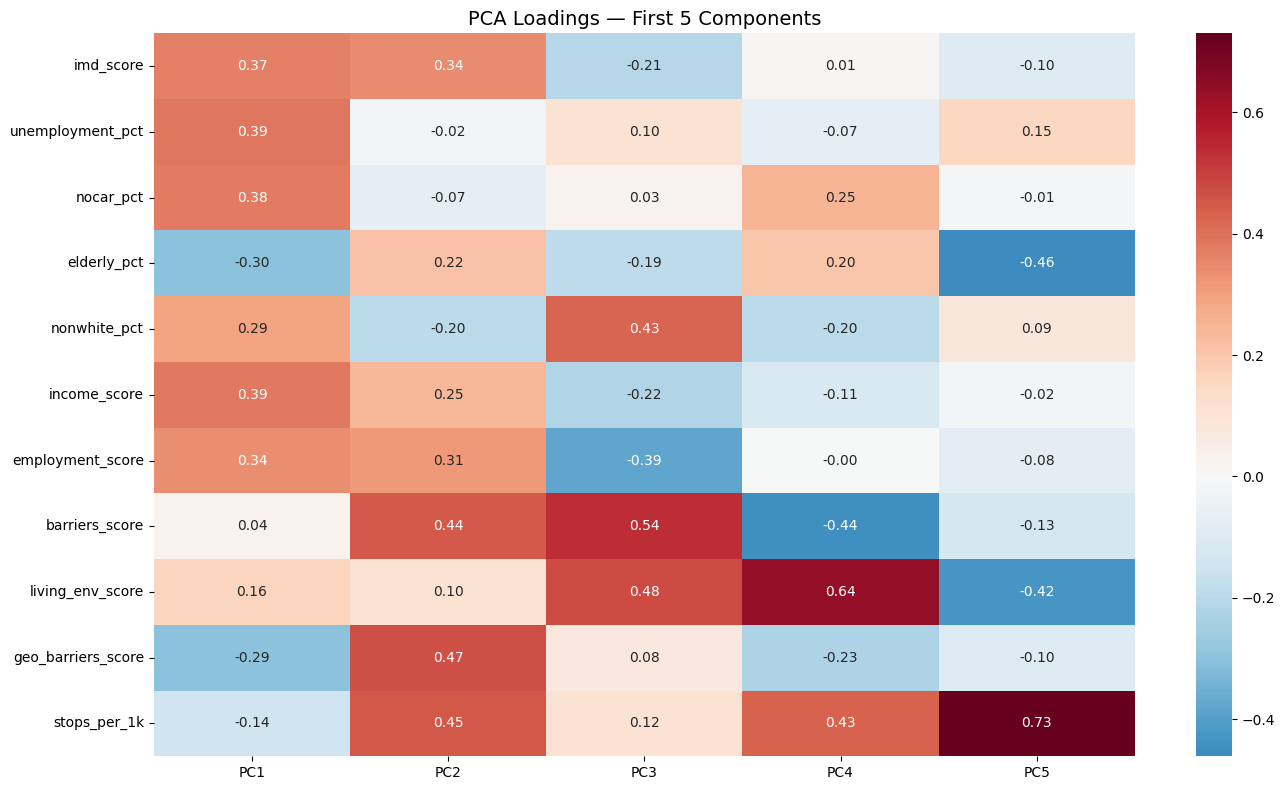

=== PCA Component Interpretation ===

PC1 (47.4% variance):
  High loadings: unemployment_pct (0.39), income_score (0.39), nocar_pct (0.38)
  Low loadings: elderly_pct (-0.30), geo_barriers_score (-0.29), stops_per_1k (-0.14)

PC2 (16.5% variance):
  High loadings: geo_barriers_score (0.47), stops_per_1k (0.45), barriers_score (0.44)
  Low loadings: nonwhite_pct (-0.20), nocar_pct (-0.07), unemployment_pct (-0.02)

PC3 (12.1% variance):
  High loadings: barriers_score (0.54), living_env_score (0.48), nonwhite_pct (0.43)
  Low loadings: employment_score (-0.39), income_score (-0.22), imd_score (-0.21)


In [6]:
# PCA loadings — what does each component mean?
loadings = pd.DataFrame(pca.components_.T, index=factor_cols,
                          columns=[f'PC{i+1}' for i in range(pca.n_components_)])

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(loadings.iloc[:, :5], annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax)
ax.set_title('PCA Loadings — First 5 Components', fontsize=14)
plt.tight_layout()
plt.show()

print("=== PCA Component Interpretation ===")
for i in range(min(3, pca.n_components_)):
    top_pos = loadings[f'PC{i+1}'].nlargest(3)
    top_neg = loadings[f'PC{i+1}'].nsmallest(3)
    print(f"\nPC{i+1} ({pca.explained_variance_ratio_[i]*100:.1f}% variance):")
    print(f"  High loadings: {', '.join([f'{k} ({v:.2f})' for k, v in top_pos.items()])}")
    print(f"  Low loadings: {', '.join([f'{k} ({v:.2f})' for k, v in top_neg.items()])}")

## 4. K-Means Clustering — LSOA Archetypes

  k=3: silhouette=0.2709, inertia=205495


  k=4: silhouette=0.2742, inertia=176906


  k=5: silhouette=0.2194, inertia=158231


  k=6: silhouette=0.2168, inertia=146386


  k=7: silhouette=0.1751, inertia=137725


  k=8: silhouette=0.1743, inertia=130712


  k=9: silhouette=0.1692, inertia=124295


  k=10: silhouette=0.1747, inertia=118337


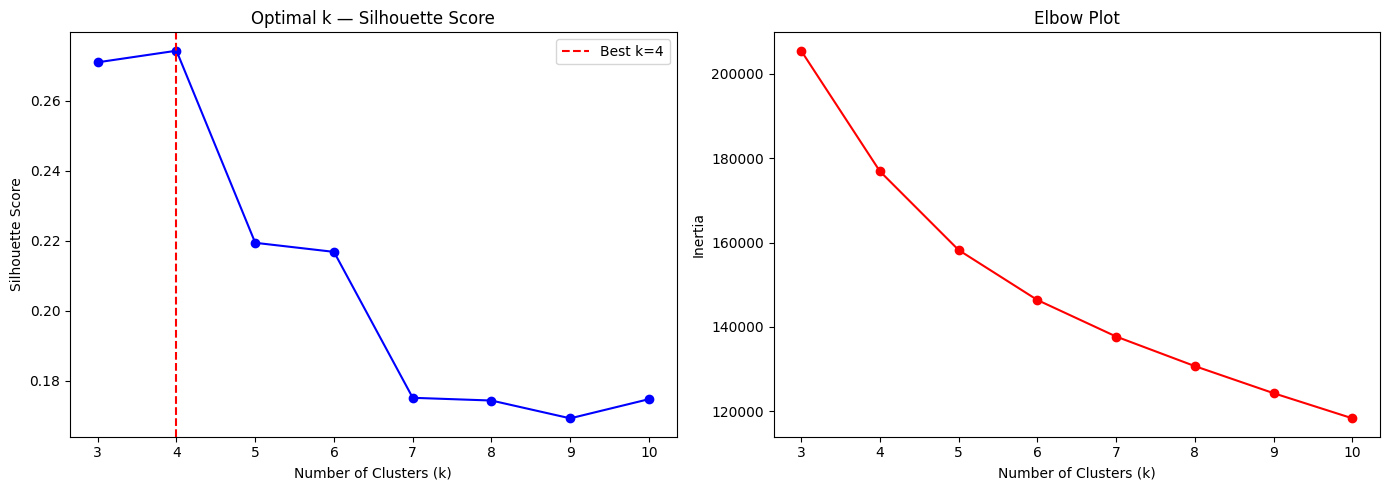


Best k by silhouette: 4


In [7]:
# Find optimal k using silhouette score
k_range = range(3, 11)
silhouette_scores = []
inertias = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels, sample_size=min(5000, len(X_scaled)))
    silhouette_scores.append(sil)
    inertias.append(km.inertia_)
    print(f"  k={k}: silhouette={sil:.4f}, inertia={km.inertia_:.0f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(k_range), silhouette_scores, 'bo-')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Silhouette Score')
axes[0].set_title('Optimal k — Silhouette Score')
best_k = list(k_range)[np.argmax(silhouette_scores)]
axes[0].axvline(best_k, color='r', linestyle='--', label=f'Best k={best_k}')
axes[0].legend()

axes[1].plot(list(k_range), inertias, 'ro-')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Inertia')
axes[1].set_title('Elbow Plot')
plt.tight_layout()
plt.show()

print(f"\nBest k by silhouette: {best_k}")

In [8]:
# Final clustering with best k
km_final = KMeans(n_clusters=best_k, random_state=42, n_init=20)
pca_data = pca_data.copy()
pca_data['cluster'] = km_final.fit_predict(X_scaled)

# Add cluster back to features
cluster_map = pca_data[['cluster']].copy()
cluster_map.index = pca_data.index
features_with_cluster = features.loc[pca_data.index].copy()
features_with_cluster['cluster'] = pca_data['cluster'].values

print(f"=== Cluster Sizes ===")
print(features_with_cluster['cluster'].value_counts().sort_index().to_string())

=== Cluster Sizes ===
cluster
0    16944
1     6023
2     4588
3     6200


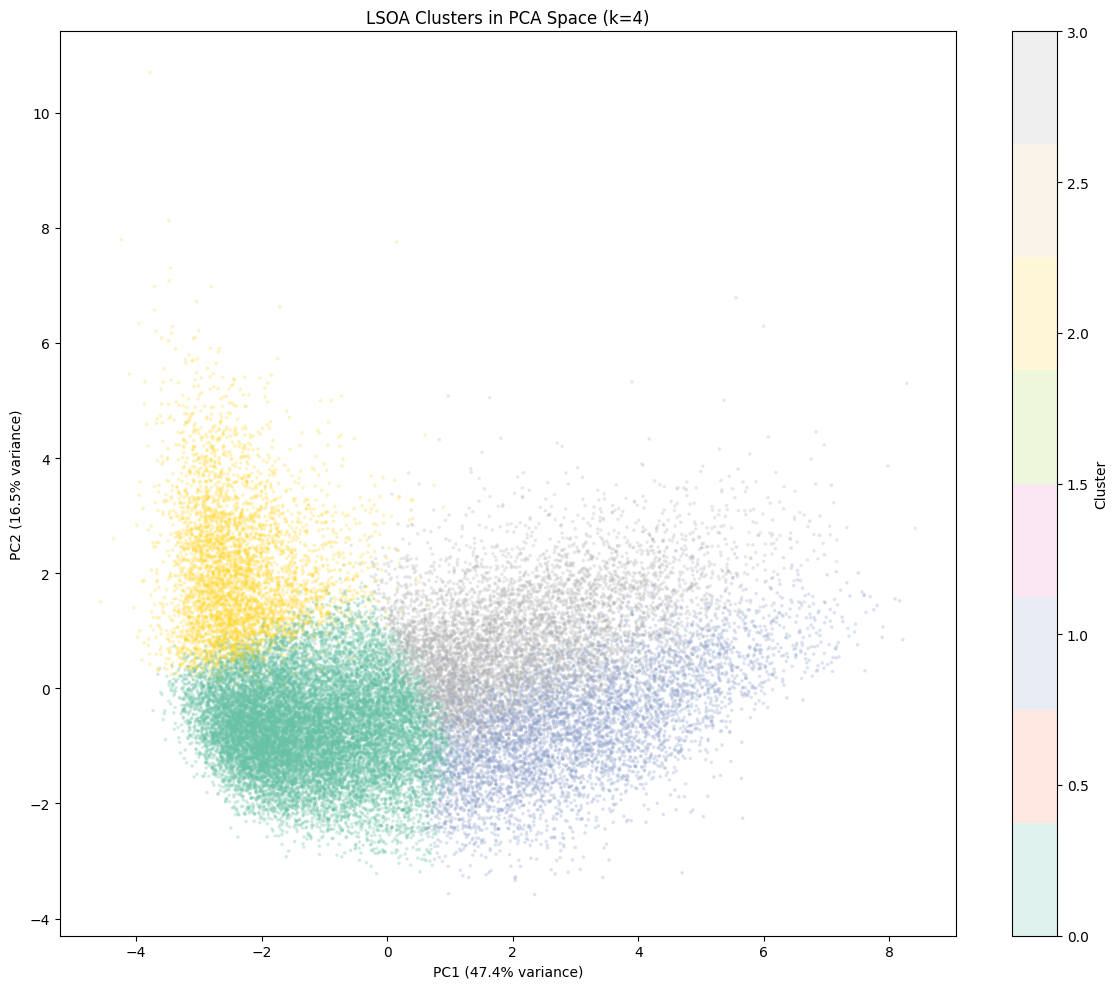

In [9]:
# PCA scatter colored by cluster
fig, ax = plt.subplots(figsize=(12, 10))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=pca_data['cluster'],
                      cmap='Set2', alpha=0.2, s=3)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.set_title(f'LSOA Clusters in PCA Space (k={best_k})')
plt.colorbar(scatter, label='Cluster')
plt.tight_layout()
plt.show()

## 5. Cluster Profiling — What Defines Each Archetype?

In [10]:
# Profile each cluster
profile_cols = [c for c in factor_cols if c in features_with_cluster.columns]
if 'ruc_class' in features_with_cluster.columns:
    # Add urban/rural as a dimension
    pass

cluster_profiles = features_with_cluster.groupby('cluster')[profile_cols].agg(['mean', 'median', 'std'])
print("=== Cluster Profiles (means) ===")
cluster_means = features_with_cluster.groupby('cluster')[profile_cols].mean()
print(cluster_means.round(2).to_string())

=== Cluster Profiles (means) ===
         imd_score  unemployment_pct  nocar_pct  elderly_pct  nonwhite_pct  income_score  employment_score  barriers_score  living_env_score  geo_barriers_score  stops_per_1k
cluster                                                                                                                                                                       
0            12.14              2.58      15.47        21.15         11.28          0.14              0.09           16.68             15.10               35.38          4.21
1            30.69              5.71      43.96         9.56         52.17          0.35              0.16           27.97             35.75               16.91          2.35
2            15.52              2.01       8.76        27.17          3.60          0.13              0.09           35.44             29.10               66.03         11.05
3            43.49              4.57      34.25        15.78         12.96          0.43    

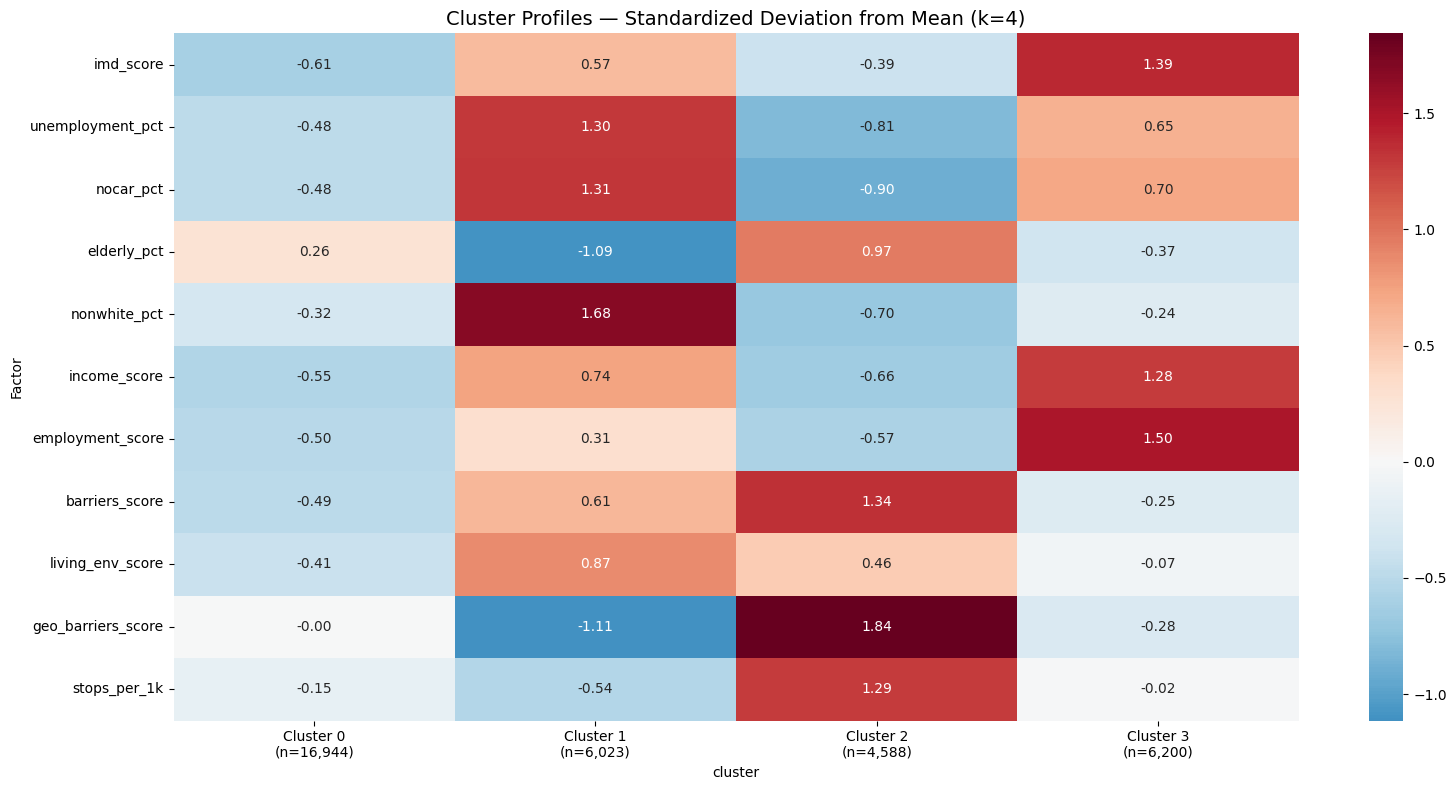

In [11]:
# Normalized heatmap — show how each cluster deviates from the overall mean
overall_mean = features_with_cluster[profile_cols].mean()
overall_std = features_with_cluster[profile_cols].std()
normalized_profiles = (cluster_means - overall_mean) / overall_std

fig, ax = plt.subplots(figsize=(16, 8))
sns.heatmap(normalized_profiles.T, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax,
            xticklabels=[f'Cluster {i}\n(n={n:,})' for i, n in
                         features_with_cluster['cluster'].value_counts().sort_index().items()])
ax.set_title(f'Cluster Profiles — Standardized Deviation from Mean (k={best_k})', fontsize=14)
ax.set_ylabel('Factor')
plt.tight_layout()
plt.show()

In [12]:
# Name the archetypes based on their profiles
print("=== Archetype Interpretation ===")
for cluster_id in sorted(features_with_cluster['cluster'].unique()):
    profile = normalized_profiles.loc[cluster_id]
    n = (features_with_cluster['cluster'] == cluster_id).sum()

    top_high = profile.nlargest(3)
    top_low = profile.nsmallest(3)

    print(f"\nCluster {cluster_id} (n={n:,}):")
    print(f"  HIGHEST: {', '.join([f'{k} (+{v:.1f}σ)' for k, v in top_high.items()])}")
    print(f"  LOWEST:  {', '.join([f'{k} ({v:.1f}σ)' for k, v in top_low.items()])}")

    # RUC breakdown
    if 'ruc_class' in features_with_cluster.columns:
        ruc_dist = features_with_cluster[features_with_cluster['cluster'] == cluster_id]['ruc_class'].value_counts(normalize=True).head(3)
        print(f"  RUC: {', '.join([f'{k} ({v*100:.0f}%)' for k, v in ruc_dist.items()])}")

=== Archetype Interpretation ===

Cluster 0 (n=16,944):
  HIGHEST: elderly_pct (+0.3σ), geo_barriers_score (+-0.0σ), stops_per_1k (+-0.1σ)
  LOWEST:  imd_score (-0.6σ), income_score (-0.6σ), employment_score (-0.5σ)
  RUC: UN1 (83%), UF1 (8%), RLN1 (7%)

Cluster 1 (n=6,023):
  HIGHEST: nonwhite_pct (+1.7σ), nocar_pct (+1.3σ), unemployment_pct (+1.3σ)
  LOWEST:  geo_barriers_score (-1.1σ), elderly_pct (-1.1σ), stops_per_1k (-0.5σ)
  RUC: UN1 (100%), UF1 (0%), RLN1 (0%)

Cluster 2 (n=4,588):
  HIGHEST: geo_barriers_score (+1.8σ), barriers_score (+1.3σ), stops_per_1k (+1.3σ)
  LOWEST:  nocar_pct (-0.9σ), unemployment_pct (-0.8σ), nonwhite_pct (-0.7σ)
  RUC: RSN1 (35%), RSF1 (21%), RLN1 (17%)

Cluster 3 (n=6,200):
  HIGHEST: employment_score (+1.5σ), imd_score (+1.4σ), income_score (+1.3σ)
  LOWEST:  elderly_pct (-0.4σ), geo_barriers_score (-0.3σ), barriers_score (-0.3σ)
  RUC: UN1 (88%), UF1 (9%), RLN1 (2%)


## 6. Multi-Deprivation Analysis

How many LSOAs are deprived on multiple dimensions simultaneously?

=== Multi-Deprivation Count ===
(Deprived = top/bottom 30% on each dimension)
  0 dimensions: 2,631 LSOAs (7.8%)
  1 dimensions: 6,212 LSOAs (18.4%)
  2 dimensions: 6,134 LSOAs (18.2%)
  3 dimensions: 4,961 LSOAs (14.7%)
  4 dimensions: 4,203 LSOAs (12.5%)
  5 dimensions: 3,240 LSOAs (9.6%)
  6 dimensions: 2,393 LSOAs (7.1%)
  7 dimensions: 1,922 LSOAs (5.7%)
  8 dimensions: 1,418 LSOAs (4.2%)
  9 dimensions: 641 LSOAs (1.9%)

  LSOAs deprived on ≥3 dimensions: 18,778
  LSOAs deprived on ≥5 dimensions: 9,614


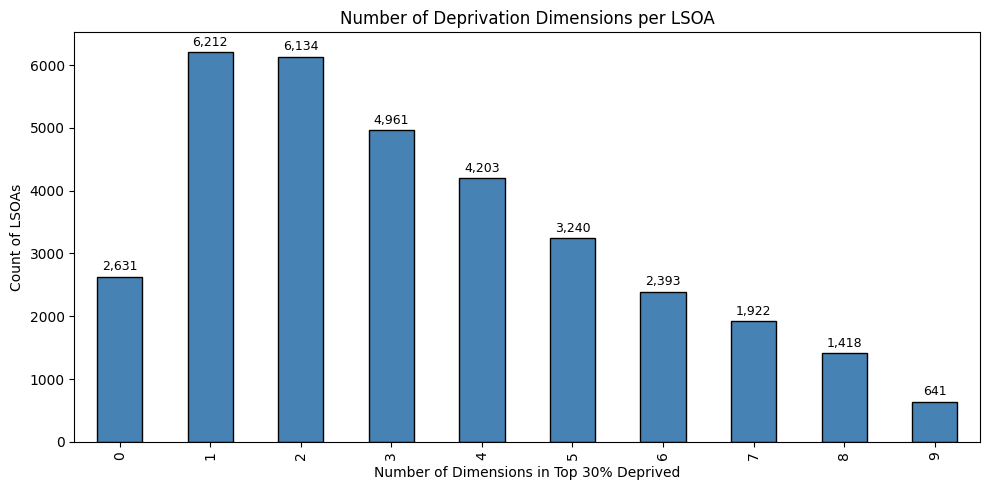

In [13]:
# Define "deprived" thresholds for each factor
dep_thresholds = {}
for c in profile_cols:
    # Top 30% = deprived (or bottom 30% for inverse metrics like stops_per_1k)
    if 'stops_per_1k' in c:
        dep_thresholds[c] = ('below', features_with_cluster[c].quantile(0.3))
    elif 'elderly_pct' in c:
        dep_thresholds[c] = ('above', features_with_cluster[c].quantile(0.7))
    else:
        dep_thresholds[c] = ('above', features_with_cluster[c].quantile(0.7))

# Count deprivation dimensions per LSOA
features_with_cluster['n_deprived'] = 0
for c, (direction, threshold) in dep_thresholds.items():
    if direction == 'above':
        features_with_cluster['n_deprived'] += (features_with_cluster[c] > threshold).astype(int)
    else:
        features_with_cluster['n_deprived'] += (features_with_cluster[c] < threshold).astype(int)

print("=== Multi-Deprivation Count ===")
print("(Deprived = top/bottom 30% on each dimension)")
dep_dist = features_with_cluster['n_deprived'].value_counts().sort_index()
for n_dep, count in dep_dist.items():
    print(f"  {n_dep} dimensions: {count:,} LSOAs ({100*count/len(features_with_cluster):.1f}%)")

print(f"\n  LSOAs deprived on ≥3 dimensions: {(features_with_cluster['n_deprived'] >= 3).sum():,}")
print(f"  LSOAs deprived on ≥5 dimensions: {(features_with_cluster['n_deprived'] >= 5).sum():,}")

fig, ax = plt.subplots(figsize=(10, 5))
dep_dist.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('Number of Deprivation Dimensions per LSOA')
ax.set_xlabel('Number of Dimensions in Top 30% Deprived')
ax.set_ylabel('Count of LSOAs')
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{int(bar.get_height()):,}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

## 7. Distribution Deep Dives — Violin Plots by Cluster

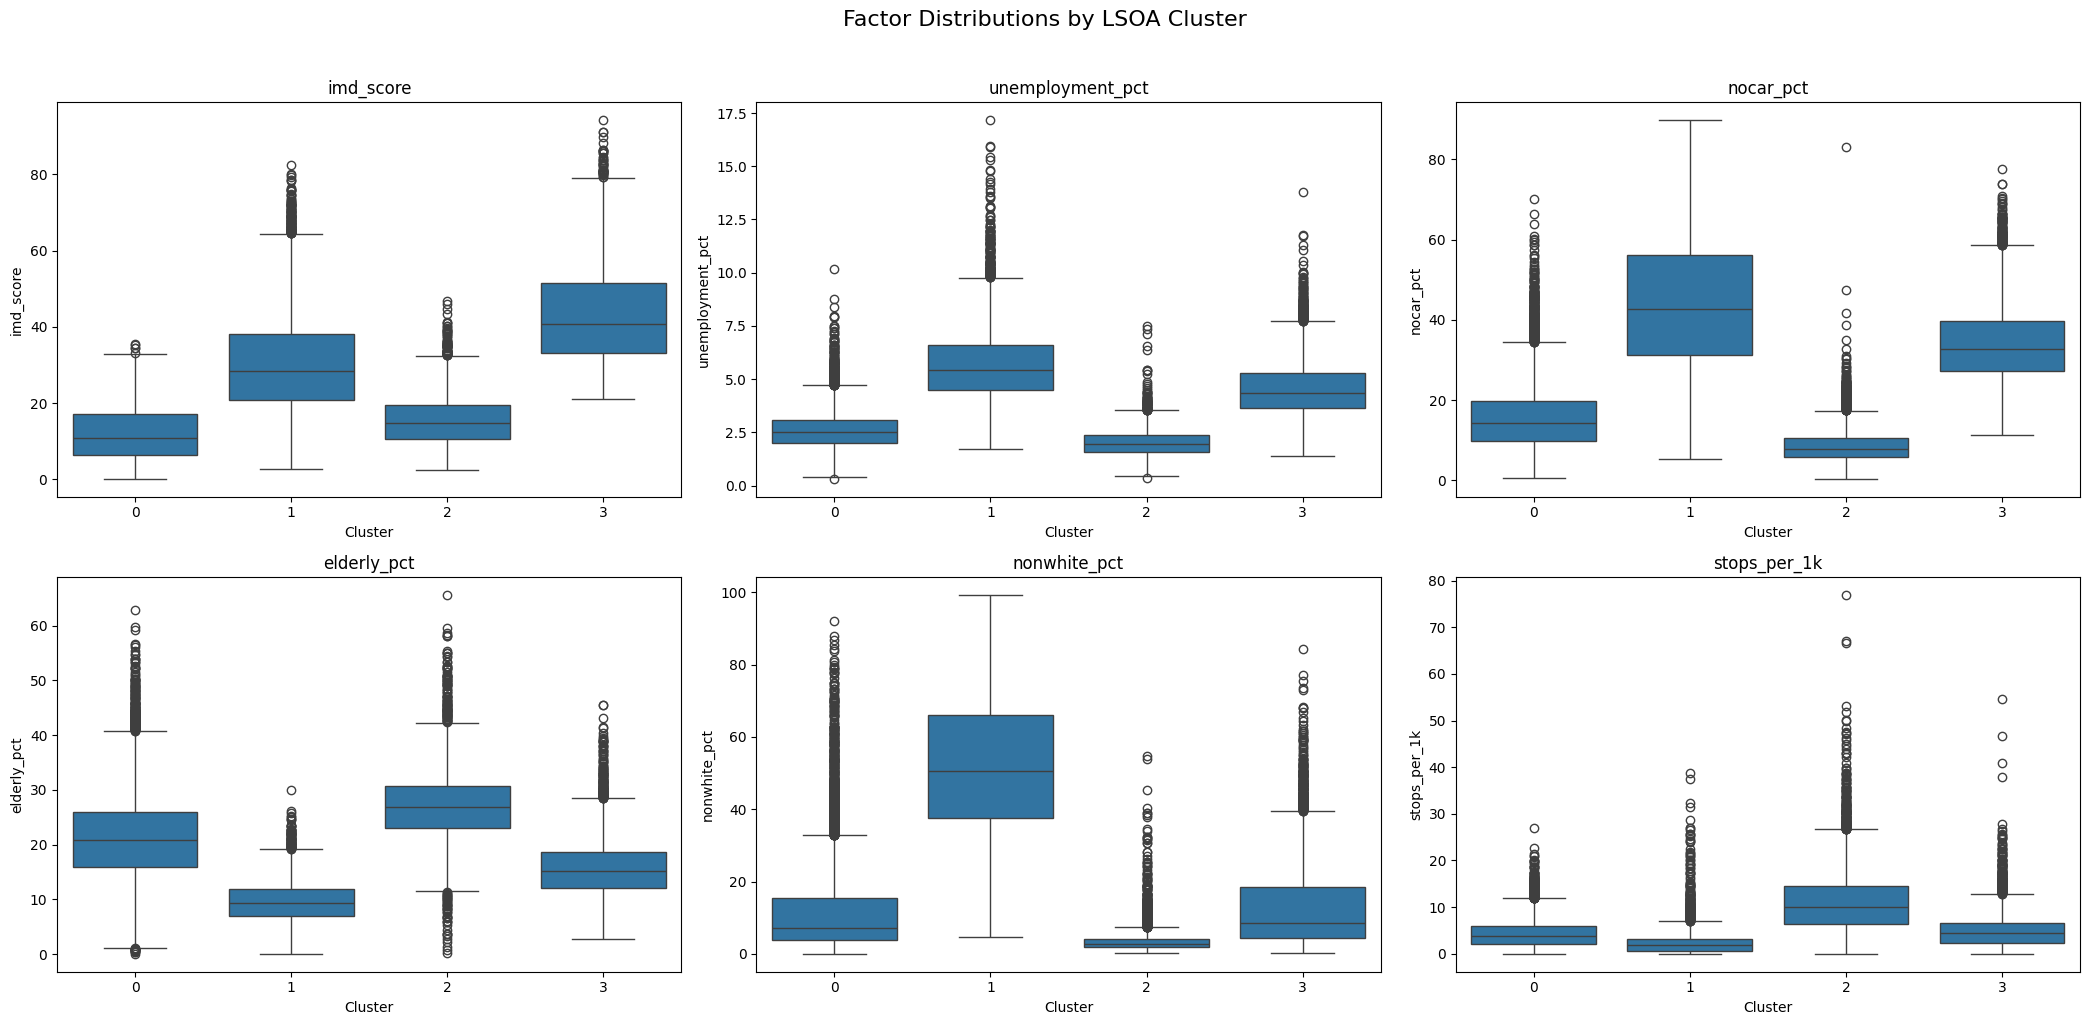

In [14]:
# Violin plots for key factors by cluster
plot_factors = [c for c in ['imd_score', 'unemployment_pct', 'nocar_pct', 'elderly_pct',
                             'nonwhite_pct', 'stops_per_1k'] if c in features_with_cluster.columns]

n_plots = len(plot_factors)
ncols = min(3, n_plots)
nrows = (n_plots + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(7*ncols, 5*nrows))
axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]

for i, col in enumerate(plot_factors):
    if i >= len(axes):
        break
    data = features_with_cluster[['cluster', col]].dropna()
    if len(data) > 0:
        sns.boxplot(data=data, x='cluster', y=col, ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('Cluster')
    axes[i].set_ylabel(col)

for j in range(len(plot_factors), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Factor Distributions by LSOA Cluster', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## 8. Box Plots — Region × Urban/Rural Cross-Cuts

In [15]:
# Load region assignments (use spatial join from 02c approach)
import geopandas as gpd

region_gdf = gpd.read_file(RAW / 'boundaries' / 'regions_2021_england_buc.geojson')
lsoa_gdf = gpd.read_file(RAW / 'boundaries' / 'lsoa_2021_england_buc.geojson')

region_name_col = [c for c in region_gdf.columns if 'nm' in c.lower() or 'name' in c.lower()][0]
lsoa_code_col = [c for c in lsoa_gdf.columns if 'cd' in c.lower() or 'code' in c.lower()][0]

# Ensure same CRS
if lsoa_gdf.crs != region_gdf.crs:
    lsoa_gdf = lsoa_gdf.to_crs(region_gdf.crs)

# Centroid-based region assignment
lsoa_centroids = lsoa_gdf.copy()
lsoa_centroids['geometry'] = lsoa_centroids.geometry.centroid
lsoa_regions = gpd.sjoin(lsoa_centroids[[lsoa_code_col, 'geometry']],
                          region_gdf[[region_name_col, 'geometry']],
                          how='left', predicate='within')

features_full = features_with_cluster.merge(
    lsoa_regions[[lsoa_code_col, region_name_col]].rename(
        columns={lsoa_code_col: 'lsoa_cd', region_name_col: 'region'}),
    on='lsoa_cd', how='left'
)

print(f"Features with region: {features_full['region'].notna().sum():,} / {len(features_full):,}")

Features with region: 33,536 / 33,755


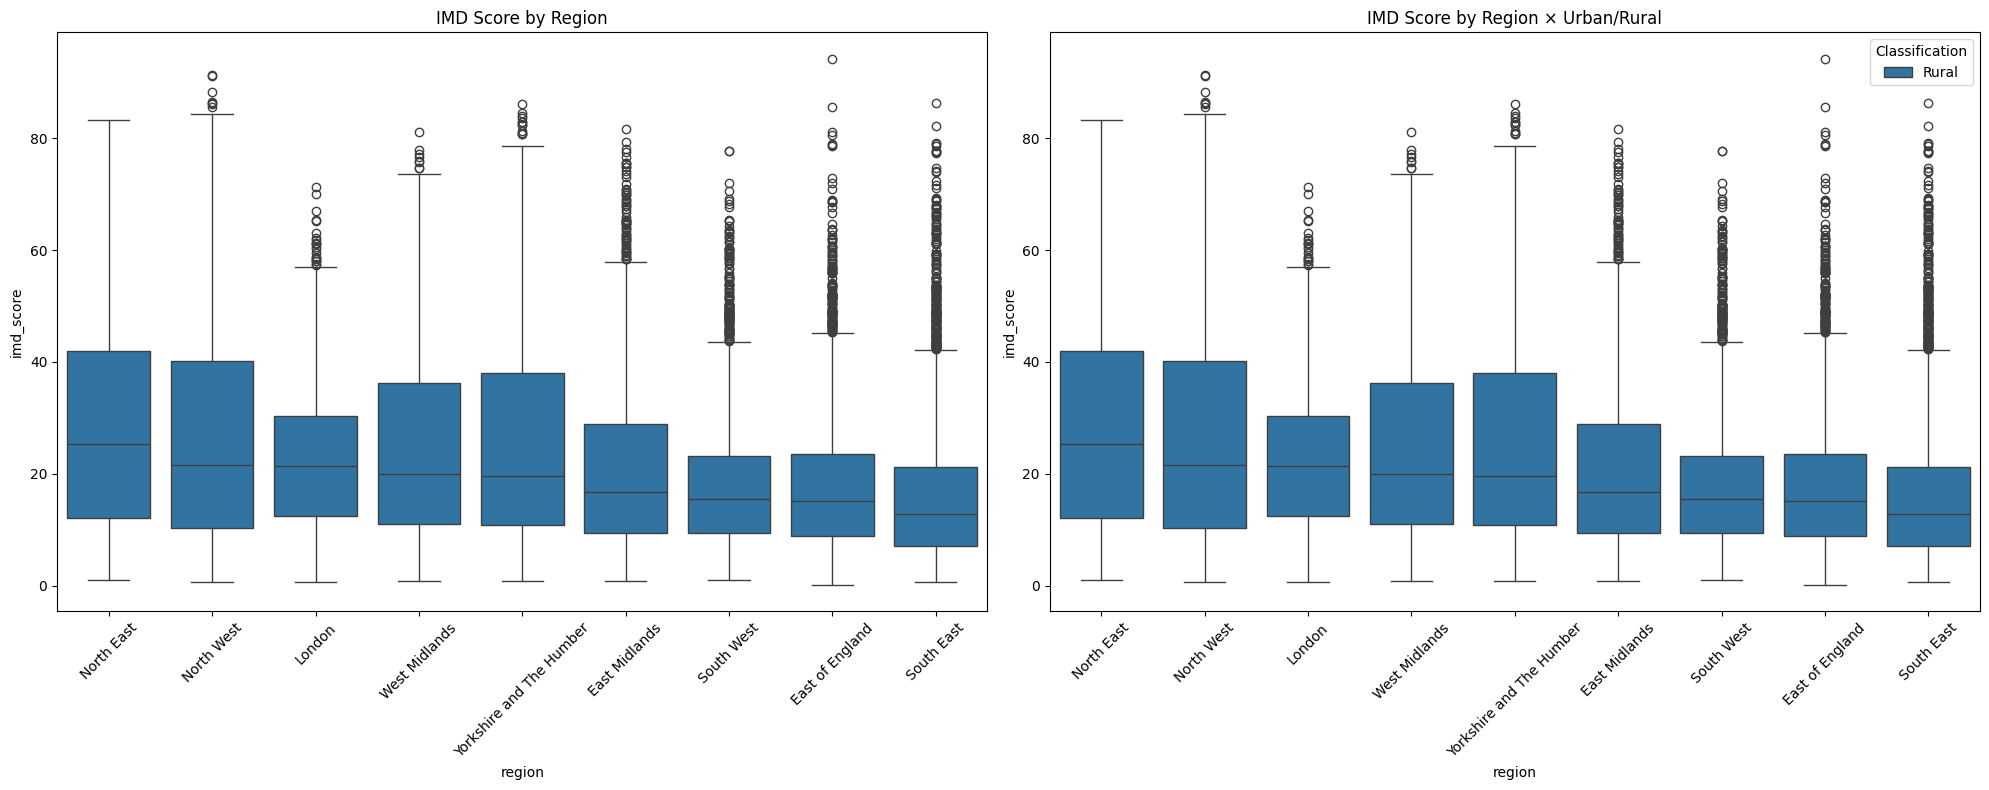

In [16]:
# IMD score by region × urban/rural
if 'ruc_class' in features_full.columns and 'region' in features_full.columns:
    # Simplify RUC to Urban/Rural binary
    features_full['is_urban'] = features_full['ruc_class'].str.contains('Urban|urban', na=False)
    features_full['urban_rural'] = features_full['is_urban'].map({True: 'Urban', False: 'Rural'})

    fig, axes = plt.subplots(1, 2, figsize=(20, 8))

    # IMD by region
    order = features_full.groupby('region')['imd_score'].median().sort_values(ascending=False).index
    sns.boxplot(data=features_full, x='region', y='imd_score', order=order, ax=axes[0])
    axes[0].set_title('IMD Score by Region')
    axes[0].tick_params(axis='x', rotation=45)

    # IMD by region × urban/rural
    sns.boxplot(data=features_full, x='region', y='imd_score', hue='urban_rural',
                order=order, ax=axes[1])
    axes[1].set_title('IMD Score by Region × Urban/Rural')
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].legend(title='Classification')

    plt.tight_layout()
    plt.show()

In [17]:
# Key factors by region
if 'region' in features_full.columns:
    region_summary = features_full.groupby('region').agg(
        n_lsoas=('imd_score', 'count'),
        mean_imd=('imd_score', 'mean'),
        mean_unemployment=('unemployment_pct', 'mean'),
        mean_nocar=('nocar_pct', 'mean'),
        mean_elderly=('elderly_pct', 'mean'),
    ).sort_values('mean_imd', ascending=False)

    print("=== Regional Factor Summary ===")
    print(region_summary.round(2).to_string())

=== Regional Factor Summary ===
                          n_lsoas  mean_imd  mean_unemployment  mean_nocar  mean_elderly
region                                                                                  
North East                   1676     28.84               3.68       27.42         20.92
North West                   4494     26.65               3.36       24.16         19.16
Yorkshire and The Humber     3340     25.76               3.36       24.00         19.55
West Midlands                3574     24.81               3.83       21.41         19.31
London                       4969     22.16               4.77       40.47         12.16
East Midlands                2847     20.87               2.99       19.12         20.03
South West                   3381     17.82               2.61       16.42         22.64
East of England              3732     17.69               2.98       16.42         19.97
South East                   5523     15.81               3.00       16.23    

## Summary

In [18]:
print("=" * 80)
print("  MULTIVARIATE ANALYSIS — KEY FINDINGS")
print("=" * 80)
print(f"""
1. PCA
   - First {n_80} components explain 80% of variance
   - PC1 likely captures overall deprivation (income + employment + health)
   - PC2 likely captures urban/rural dimension (barriers + elderly)

2. CLUSTERING
   - Best k = {best_k} by silhouette score
   - Each cluster represents a distinct LSOA archetype
   - Archetypes differ on multiple dimensions simultaneously

3. MULTI-DEPRIVATION
   - {(features_with_cluster['n_deprived'] >= 3).sum():,} LSOAs deprived on ≥3 dimensions
   - {(features_with_cluster['n_deprived'] >= 5).sum():,} LSOAs deprived on ≥5 dimensions
   - These are the highest-priority areas for policy intervention

4. IMPLICATIONS FOR PIPELINE
   - Cluster assignments can feed InsightEngine narratives
   - Multi-deprivation count → priority scoring
   - Region × urban/rural → structural context for all metrics
""")

# Save feature matrix with clusters
features_with_cluster.to_parquet(AUDIT / 'lsoa_feature_matrix_clustered.parquet', index=False)
print("Saved feature matrix with clusters to data/audit/lsoa_feature_matrix_clustered.parquet")
print("\n02e — Multivariate Clustering: DONE")

  MULTIVARIATE ANALYSIS — KEY FINDINGS

1. PCA
   - First 4 components explain 80% of variance
   - PC1 likely captures overall deprivation (income + employment + health)
   - PC2 likely captures urban/rural dimension (barriers + elderly)

2. CLUSTERING
   - Best k = 4 by silhouette score
   - Each cluster represents a distinct LSOA archetype
   - Archetypes differ on multiple dimensions simultaneously

3. MULTI-DEPRIVATION
   - 18,778 LSOAs deprived on ≥3 dimensions
   - 9,614 LSOAs deprived on ≥5 dimensions
   - These are the highest-priority areas for policy intervention

4. IMPLICATIONS FOR PIPELINE
   - Cluster assignments can feed InsightEngine narratives
   - Multi-deprivation count → priority scoring
   - Region × urban/rural → structural context for all metrics

Saved feature matrix with clusters to data/audit/lsoa_feature_matrix_clustered.parquet

02e — Multivariate Clustering: DONE
